<a href="https://colab.research.google.com/github/IanPerigoUERN/NexVisual/blob/main/NexVisual_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Modelos Generativos**

# **Modelos Multimodais**

In [4]:
!pip install torch torchvision

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision

In [10]:
# Carregar base de dados do mnist

batch_size = 100  ### Usar número que será um denominador onde a divisão do dataloader por ele dê zero
# ou corrigir o tamanho do vetor em D_train e G_train

# MNIST Dataset.
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=(0.5), std=(0.5))])

train_dataset = torchvision.datasets.MNIST(root='./mnist_data/', train=True, transform=transform, download=True)
# Data Loader.
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)

In [11]:
# Gerador. criando imagens com base no dataset de treino
class Generator(torch.nn.Module):
    def __init__(self, g_input_dim, g_output_dim):
        super(Generator, self).__init__()
        self.fc1 = torch.nn.Linear(g_input_dim, 256)
        self.fc2 = torch.nn.Linear(self.fc1.out_features, self.fc1.out_features*2) # 256 e 512
        self.fc3 = torch.nn.Linear(self.fc2.out_features, self.fc2.out_features*2) #512 e 1024
        self.fc4 = torch.nn.Linear(self.fc3.out_features, g_output_dim)            # 1024 e output

    # método forward.
    def forward(self, x):
        x = torch.nn.functional.leaky_relu(self.fc1(x), 0.2)
        x = torch.nn.functional.leaky_relu(self.fc2(x), 0.2)
        x = torch.nn.functional.leaky_relu(self.fc3(x), 0.2)
        return torch.tanh(self.fc4(x))   # valores entre -1 e 1

# Discrimador . Imagem verdadeira ou falsa ?
class Discriminator(torch.nn.Module):
    def __init__(self, d_input_dim):
        super(Discriminator, self).__init__()
        self.fc1 = torch.nn.Linear(d_input_dim, 1024)
        self.fc2 = torch.nn.Linear(self.fc1.out_features, self.fc1.out_features//2)
        self.fc3 = torch.nn.Linear(self.fc2.out_features, self.fc2.out_features//2)
        self.fc4 = torch.nn.Linear(self.fc3.out_features, 1)

    # método forward.
    def forward(self, x):
        x = torch.nn.functional.leaky_relu(self.fc1(x), 0.2)
        x = torch.nn.functional.dropout(x, 0.3)
        x = torch.nn.functional.leaky_relu(self.fc2(x), 0.2)
        x = torch.nn.functional.dropout(x, 0.3)
        x = torch.nn.functional.leaky_relu(self.fc3(x), 0.2)
        x = torch.nn.functional.dropout(x, 0.3) # Remoção de neurônios aleatórias para evitar overfing
        return torch.sigmoid(self.fc4(x))  # Sigmoid > valores entre 0 e 1 (falsa ou verdadeira)

In [12]:
# Instanciar as redes.
z_dim = 100
mnist_dim = train_dataset.train_data.size(1) * train_dataset.train_data.size(2)

device = "cuda" if torch.cuda.is_available() else "cpu"
G = Generator(g_input_dim = z_dim, g_output_dim = mnist_dim).to(device)
D = Discriminator(mnist_dim).to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:76: UserWarning: train_data has been renamed data
  warnings.warn("train_data has been renamed data")


In [13]:
# Função de perda.
criterion = torch.nn.BCELoss()

# Otimizador.
lr = 0.0002
G_optimizer = torch.optim.Adam(G.parameters(), lr = lr)
D_optimizer = torch.optim.Adam(D.parameters(), lr = lr)


In [7]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

!nvidia-smi

True
Tesla T4
Sun Jun  7 12:15:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P0             26W /   70W |     127MiB /  15360MiB |      4%      Default |
|                                         |                        |                  N/A |
+---------------------------------

In [14]:
def D_train(x):
    #=======================Treino do discriminador=======================#
    D.zero_grad()

    # Treina discriminador em dados reais.
    x_real, y_real = x.view(-1, mnist_dim), torch.ones(batch_size, 1)
    x_real, y_real = torch.autograd.Variable(x_real.to(device)), torch.autograd.Variable(y_real.to(device))

    D_output = D(x_real)
    D_real_loss = criterion(D_output, y_real)
    D_real_score = D_output

    # Treina discriminador em dados falsos.
    z = torch.autograd.Variable(torch.randn(batch_size, z_dim).to(device))
    x_fake, y_fake = G(z), torch.autograd.Variable(torch.zeros(batch_size, 1).to(device))

    D_output = D(x_fake)
    D_fake_loss = criterion(D_output, y_fake)
    D_fake_score = D_output

    # Backpropagation e otimização dos parâmetros do discriminador.
    D_loss = D_real_loss + D_fake_loss
    D_loss.backward()
    D_optimizer.step()

    return  D_loss.data.item()

def G_train(x):
    #=======================Treino do gerador=======================#
    G.zero_grad()

    z = torch.autograd.Variable(torch.randn(batch_size, z_dim).to(device))
    y = torch.autograd.Variable(torch.ones(batch_size, 1).to(device))

    G_output = G(z)
    D_output = D(G_output)
    G_loss = criterion(D_output, y)

    # Backpropagation e otimização dos parâmetros do gerador.
    G_loss.backward()
    G_optimizer.step()

    return G_loss.data.item()

In [15]:
# Laço de treino.
n_epoch = 200
for epoch in range(1, n_epoch+1):
    D_losses, G_losses = [], []
    for batch_idx, (x, _) in enumerate(train_loader):
        D_losses.append(D_train(x))
        G_losses.append(G_train(x))

    print('[%d/%d]: loss_d: %.3f, loss_g: %.3f' % (
            (epoch), n_epoch, torch.mean(torch.FloatTensor(D_losses)), torch.mean(torch.FloatTensor(G_losses))))

[1/200]: loss_d: 0.822, loss_g: 3.364
[2/200]: loss_d: 0.812, loss_g: 3.898
[3/200]: loss_d: 0.978, loss_g: 2.015
[4/200]: loss_d: 0.757, loss_g: 2.429
[5/200]: loss_d: 0.462, loss_g: 2.899
[6/200]: loss_d: 0.462, loss_g: 2.722
[7/200]: loss_d: 0.494, loss_g: 2.735
[8/200]: loss_d: 0.570, loss_g: 2.597
[9/200]: loss_d: 0.593, loss_g: 2.506
[10/200]: loss_d: 0.653, loss_g: 2.313
[11/200]: loss_d: 0.668, loss_g: 2.281
[12/200]: loss_d: 0.705, loss_g: 2.074
[13/200]: loss_d: 0.832, loss_g: 1.755
[14/200]: loss_d: 0.788, loss_g: 1.828
[15/200]: loss_d: 0.817, loss_g: 1.866
[16/200]: loss_d: 0.826, loss_g: 1.817
[17/200]: loss_d: 0.841, loss_g: 1.708
[18/200]: loss_d: 0.868, loss_g: 1.694
[19/200]: loss_d: 0.908, loss_g: 1.601
[20/200]: loss_d: 0.898, loss_g: 1.624
[21/200]: loss_d: 0.905, loss_g: 1.599
[22/200]: loss_d: 0.893, loss_g: 1.637
[23/200]: loss_d: 0.945, loss_g: 1.526
[24/200]: loss_d: 0.960, loss_g: 1.493
[25/200]: loss_d: 0.952, loss_g: 1.506
[26/200]: loss_d: 0.979, loss_g: 1

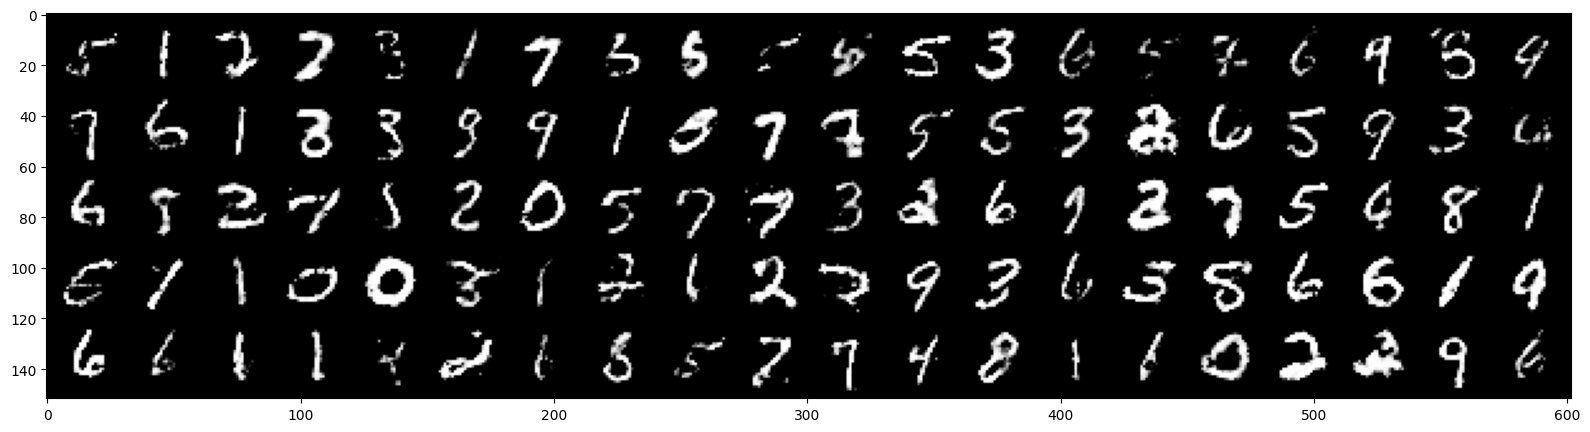

In [16]:
# Inferência com modelo treinado.
with torch.no_grad():
    test_z = torch.autograd.Variable(torch.randn(batch_size, z_dim).to(device))
    generated = G(test_z)

generated = generated.view(generated.size(0), 1, 28, 28)
grid = torchvision.utils.make_grid(generated.cpu(), 20)
grid = grid.permute(1, 2, 0).numpy()
plt.figure(figsize=(20, 5))
plt.imshow(grid.squeeze(), cmap='gray')


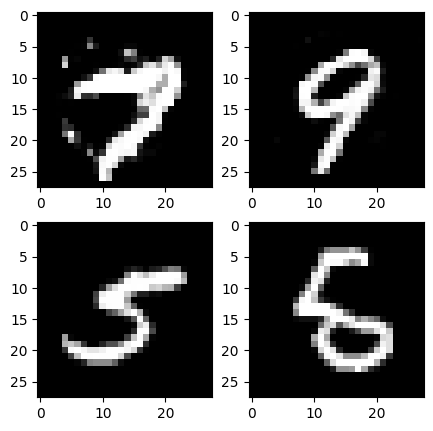

In [17]:
# Comparação resultados dos modelos e dados da base.
indexes_gen = [np.random.randint(0, batch_size), np.random.randint(0, batch_size)]
indexes_data = [np.random.randint(0, len(train_dataset)), np.random.randint(0, len(train_dataset))]

index = 0

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(5, 5))
axes[0, 0].imshow(generated.view(generated.size(0), 1, 28, 28).cpu().numpy()[indexes_gen[0]].transpose(1, 2, 0), cmap="gray")
axes[0, 1].imshow(generated.view(generated.size(0), 1, 28, 28).cpu().numpy()[indexes_gen[1]].transpose(1, 2, 0), cmap="gray")
axes[1, 0].imshow(train_dataset[indexes_data[0]][0].numpy().transpose(1,2,0), cmap="gray")
axes[1, 1].imshow(train_dataset[indexes_data[1]][0].numpy().transpose(1,2,0), cmap="gray")

# **Agora vamos tentar com outra base de dados**

# **Vamos usar o KMNIST que possui caracteres japoneses históricos**

In [3]:
from torchvision.datasets import KMNIST
from torchvision import transforms
from torch.utils.data import DataLoader

In [6]:
# =====================================================
# Dataset
# =====================================================

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = KMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

batch_size = 100

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=True
)

100%|██████████| 18.2M/18.2M [00:10<00:00, 1.75MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 327kB/s]
100%|██████████| 3.04M/3.04M [00:01<00:00, 2.15MB/s]
100%|██████████| 5.12k/5.12k [00:00<00:00, 6.27MB/s]


In [7]:
# Gerador. criando imagens com base no dataset de treino
class Generator(torch.nn.Module):
    def __init__(self, g_input_dim, g_output_dim):
        super(Generator, self).__init__()
        self.fc1 = torch.nn.Linear(g_input_dim, 256)
        self.fc2 = torch.nn.Linear(self.fc1.out_features, self.fc1.out_features*2) # 256 e 512
        self.fc3 = torch.nn.Linear(self.fc2.out_features, self.fc2.out_features*2) #512 e 1024
        self.fc4 = torch.nn.Linear(self.fc3.out_features, g_output_dim)            # 1024 e output

    # método forward.
    def forward(self, x):
        x = torch.nn.functional.leaky_relu(self.fc1(x), 0.2)
        x = torch.nn.functional.leaky_relu(self.fc2(x), 0.2)
        x = torch.nn.functional.leaky_relu(self.fc3(x), 0.2)
        return torch.tanh(self.fc4(x))   # valores entre -1 e 1

# Discrimador . Imagem verdadeira ou falsa ?
class Discriminator(torch.nn.Module):
    def __init__(self, d_input_dim):
        super(Discriminator, self).__init__()
        self.fc1 = torch.nn.Linear(d_input_dim, 1024)
        self.fc2 = torch.nn.Linear(self.fc1.out_features, self.fc1.out_features//2)
        self.fc3 = torch.nn.Linear(self.fc2.out_features, self.fc2.out_features//2)
        self.fc4 = torch.nn.Linear(self.fc3.out_features, 1)

    # método forward.
    def forward(self, x):
        x = torch.nn.functional.leaky_relu(self.fc1(x), 0.2)
        x = torch.nn.functional.dropout(x, 0.3)
        x = torch.nn.functional.leaky_relu(self.fc2(x), 0.2)
        x = torch.nn.functional.dropout(x, 0.3)
        x = torch.nn.functional.leaky_relu(self.fc3(x), 0.2)
        x = torch.nn.functional.dropout(x, 0.3) # Remoção de neurônios aleatórias para evitar overfing
        return torch.sigmoid(self.fc4(x))  # Sigmoid > valores entre 0 e 1 (falsa ou verdadeira)

In [8]:
# Instanciar as redes.
z_dim = 100
mnist_dim = train_dataset.train_data.size(1) * train_dataset.train_data.size(2)

device = "cuda" if torch.cuda.is_available() else "cpu"
G = Generator(g_input_dim = z_dim, g_output_dim = mnist_dim).to(device)
D = Discriminator(mnist_dim).to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:76: UserWarning: train_data has been renamed data
  warnings.warn("train_data has been renamed data")


In [11]:
# Função de perda.
criterion = torch.nn.BCELoss()

# Otimizador.
lr = 0.0002
G_optimizer = torch.optim.Adam(G.parameters(), lr = lr)
D_optimizer = torch.optim.Adam(D.parameters(), lr = lr)


In [9]:
def D_train(x):
    #=======================Treino do discriminador=======================#
    D.zero_grad()

    # Treina discriminador em dados reais.
    x_real, y_real = x.view(-1, mnist_dim), torch.ones(batch_size, 1)
    x_real, y_real = torch.autograd.Variable(x_real.to(device)), torch.autograd.Variable(y_real.to(device))

    D_output = D(x_real)
    D_real_loss = criterion(D_output, y_real)
    D_real_score = D_output

    # Treina discriminador em dados falsos.
    z = torch.autograd.Variable(torch.randn(batch_size, z_dim).to(device))
    x_fake, y_fake = G(z), torch.autograd.Variable(torch.zeros(batch_size, 1).to(device))

    D_output = D(x_fake)
    D_fake_loss = criterion(D_output, y_fake)
    D_fake_score = D_output

    # Backpropagation e otimização dos parâmetros do discriminador.
    D_loss = D_real_loss + D_fake_loss
    D_loss.backward()
    D_optimizer.step()

    return  D_loss.data.item()

def G_train(x):
    #=======================Treino do gerador=======================#
    G.zero_grad()

    z = torch.autograd.Variable(torch.randn(batch_size, z_dim).to(device))
    y = torch.autograd.Variable(torch.ones(batch_size, 1).to(device))

    G_output = G(z)
    D_output = D(G_output)
    G_loss = criterion(D_output, y)

    # Backpropagation e otimização dos parâmetros do gerador.
    G_loss.backward()
    G_optimizer.step()

    return G_loss.data.item()

In [12]:
# =====================================================
# Loop de treino
# =====================================================

G.train()
D.train()

n_epoch = 100

for epoch in range(n_epoch):

    D_losses = []
    G_losses = []

    for batch_idx, (x, _) in enumerate(train_loader):

        D_losses.append(
            D_train(x)
        )

        G_losses.append(
            G_train(x)
        )

    avg_d = sum(D_losses) / len(D_losses)
    avg_g = sum(G_losses) / len(G_losses)

    print(
        f"[{epoch+1}/{n_epoch}] "
        f"loss_d: {avg_d:.4f} "
        f"loss_g: {avg_g:.4f}"
    )

[1/100] loss_d: 0.9098 loss_g: 3.4926
[2/100] loss_d: 0.7158 loss_g: 3.1587
[3/100] loss_d: 0.7283 loss_g: 2.4459
[4/100] loss_d: 0.5630 loss_g: 3.1730
[5/100] loss_d: 0.4947 loss_g: 3.2052
[6/100] loss_d: 0.5189 loss_g: 3.0656
[7/100] loss_d: 0.4996 loss_g: 3.0680
[8/100] loss_d: 0.4188 loss_g: 3.3823
[9/100] loss_d: 0.4728 loss_g: 3.1116
[10/100] loss_d: 0.4892 loss_g: 3.0178
[11/100] loss_d: 0.5182 loss_g: 2.8080
[12/100] loss_d: 0.5712 loss_g: 2.6998
[13/100] loss_d: 0.5550 loss_g: 2.7264
[14/100] loss_d: 0.5746 loss_g: 2.6785
[15/100] loss_d: 0.6290 loss_g: 2.4779
[16/100] loss_d: 0.6242 loss_g: 2.4786
[17/100] loss_d: 0.6468 loss_g: 2.4148
[18/100] loss_d: 0.6711 loss_g: 2.3737
[19/100] loss_d: 0.6549 loss_g: 2.3804
[20/100] loss_d: 0.6460 loss_g: 2.3893
[21/100] loss_d: 0.6742 loss_g: 2.3125
[22/100] loss_d: 0.6684 loss_g: 2.2899
[23/100] loss_d: 0.6763 loss_g: 2.2730
[24/100] loss_d: 0.6925 loss_g: 2.2026
[25/100] loss_d: 0.7041 loss_g: 2.1865
[26/100] loss_d: 0.6843 loss_g: 2.

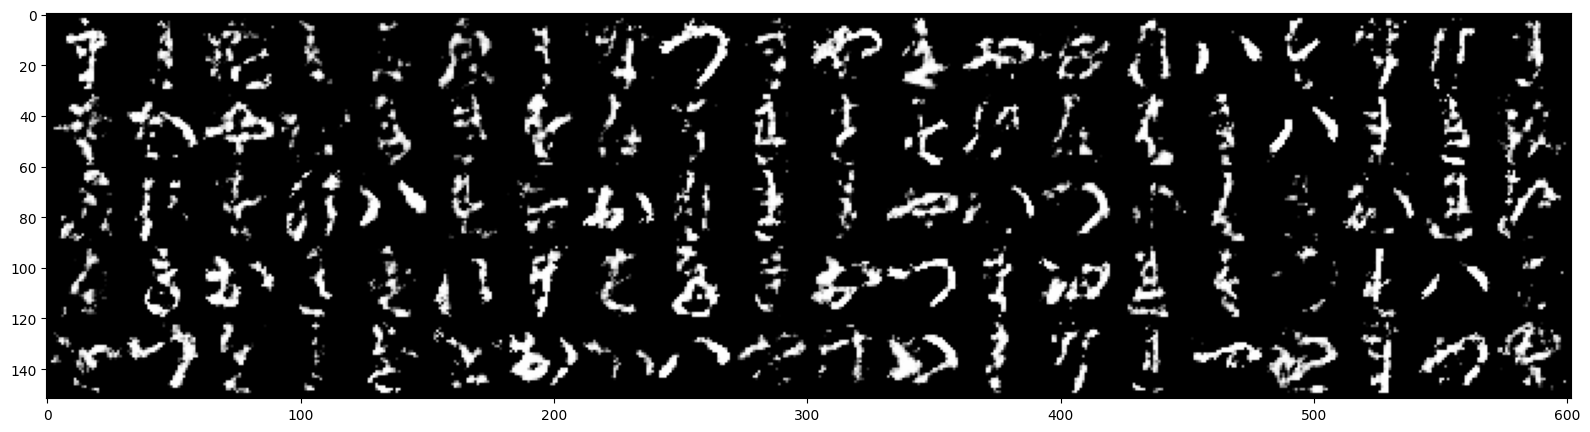

In [13]:
# Inferência com modelo treinado.
with torch.no_grad():
    test_z = torch.autograd.Variable(torch.randn(batch_size, z_dim).to(device))
    generated = G(test_z)

generated = generated.view(generated.size(0), 1, 28, 28)
grid = torchvision.utils.make_grid(generated.cpu(), 20)
grid = grid.permute(1, 2, 0).numpy()
plt.figure(figsize=(20, 5))
plt.imshow(grid.squeeze(), cmap='gray')


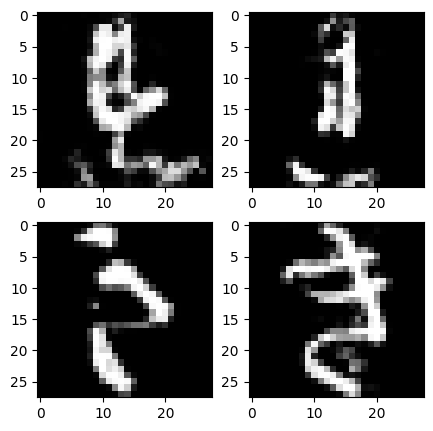

In [14]:
# Comparação resultados dos modelos e dados da base.
indexes_gen = [np.random.randint(0, batch_size), np.random.randint(0, batch_size)]
indexes_data = [np.random.randint(0, len(train_dataset)), np.random.randint(0, len(train_dataset))]

index = 0

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(5, 5))
axes[0, 0].imshow(generated.view(generated.size(0), 1, 28, 28).cpu().numpy()[indexes_gen[0]].transpose(1, 2, 0), cmap="gray")
axes[0, 1].imshow(generated.view(generated.size(0), 1, 28, 28).cpu().numpy()[indexes_gen[1]].transpose(1, 2, 0), cmap="gray")
axes[1, 0].imshow(train_dataset[indexes_data[0]][0].numpy().transpose(1,2,0), cmap="gray")
axes[1, 1].imshow(train_dataset[indexes_data[1]][0].numpy().transpose(1,2,0), cmap="gray")

# **Vejamos abaixo como os caracteres Kuzushiji são**

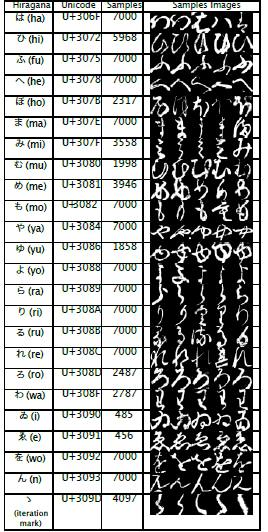

# **Modelos Multimodais**

In [1]:
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-3n47t29n
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-3n47t29n
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.3 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=c921690bd134b809424e81f630a4af92084f3424b844e5e9a51e58659110d8fb
  Stored in directory: /tmp/pip-ephem-wheel-cache-ypksq87p/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [10]:
import torch
import clip
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import drive
from google.colab.patches import cv2_imshow
import cv2

import os

In [21]:




drive.mount('/content/drive')


directory = '/content/drive/MyDrive/nexvisual_files/'


os.makedirs(directory, exist_ok=True)

image = cv2.imread(directory +'camaleao.jpeg')

image2 = cv2.imread(directory +'india.jpg')

#cv2_imshow(image)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


['animal', 'colorful', 'plants', 'chameleon', 'reptile', 'lizard']
Probabilidades imagem vs. textos: [0.09% de "animal", 2.06% de "colorful", 0.00% de "plants", 94.88% de "chameleon", 0.82% de "reptile", 2.16% de "lizard"]


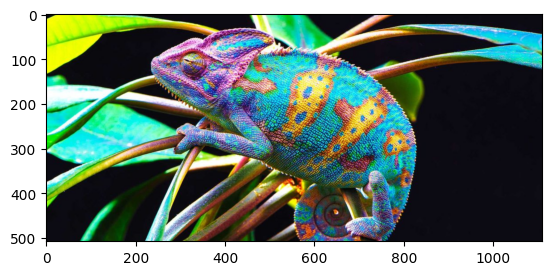

In [27]:
# Path para a imagem.
#path_image = "images/rio.jpeg"
# path_image = "images/dog.jpeg"

# Textos para avaliar.
texts = ["animal", "colorful", "plants", "chameleon","reptile","lizard"]
# texts = ["a cat", "a dog", "a diagram"]

# Define o dispositivo a carregar o modelo.
device = "cuda" if torch.cuda.is_available() else "cpu"

# Carrega o modelo com o backbone do ViT-B/32.
model, preprocess = clip.load("ViT-B/32", device=device)


# Processa a imagem.
# Converter o array NumPy de BGR para RGB e depois para PIL Image
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
pil_image = Image.fromarray(image_rgb)
image_processed = preprocess(pil_image).unsqueeze(0).to(device)

# Processa o texto.
text = clip.tokenize(texts).to(device)

# Roda inferências.
with torch.no_grad():
    _ = model.encode_image(image_processed) # Encoda imagem.
    _ = model.encode_text(text) # Encoda o texto.

    logits_per_image, logits_per_text = model(image_processed, text) # Computa similaridade entre imagem e textos.
    probs = logits_per_image.softmax(dim=-1).cpu().numpy()[0] # Retorna probabilidades.

formated_probs_str = '[' + ', '.join(f'{x * 100:.2f}% de "{t}"' for x, t in zip(list(probs), texts)) + ']'

plt.imshow(pil_image) # Display the PIL image
print(texts)
print("Probabilidades imagem vs. textos:", formated_probs_str)


['car', 'rush', 'traffic', 'motorcycle', 'traffic jam']
Probabilidades imagem vs. textos: [2.13% de "car", 0.02% de "rush", 19.91% de "traffic", 0.43% de "motorcycle", 77.56% de "traffic jam"]


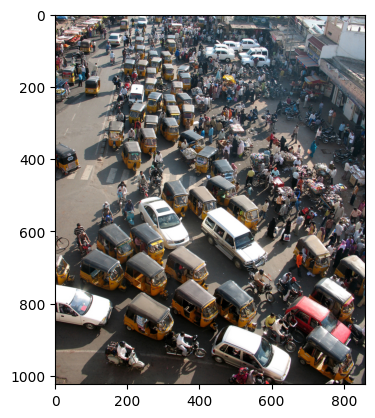

In [23]:
# Path para a imagem.
#path_image = "images/rio.jpeg"
# path_image = "images/dog.jpeg"

# Textos para avaliar.
texts = ["car", "rush", "traffic", "motorcycle","traffic jam"]
# texts = ["a cat", "a dog", "a diagram"]

# Define o dispositivo a carregar o modelo.
device = "cuda" if torch.cuda.is_available() else "cpu"

# Carrega o modelo com o backbone do ViT-B/32.
model, preprocess = clip.load("ViT-B/32", device=device)


# Processa a imagem.
# Converter o array NumPy de BGR para RGB e depois para PIL Image
image_rgb = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)
pil_image = Image.fromarray(image_rgb)
image_processed = preprocess(pil_image).unsqueeze(0).to(device)

# Processa o texto.
text = clip.tokenize(texts).to(device)

# Roda inferências.
with torch.no_grad():
    _ = model.encode_image(image_processed) # Encoda imagem.
    _ = model.encode_text(text) # Encoda o texto.

    logits_per_image, logits_per_text = model(image_processed, text) # Computa similaridade entre imagem e textos.
    probs = logits_per_image.softmax(dim=-1).cpu().numpy()[0] # Retorna probabilidades.

formated_probs_str = '[' + ', '.join(f'{x * 100:.2f}% de "{t}"' for x, t in zip(list(probs), texts)) + ']'

plt.imshow(pil_image) # Display the PIL image
print(texts)
print("Probabilidades imagem vs. textos:", formated_probs_str)
